## Lecture 4 Exercises: QC GWAS

1) Missingness of SNPs and Individuals (20 pts)
a. Provide PLINK + bash commands used to compute individual and SNP missingness.
b. Plot individual missingness histogram.
c. Plot SNP missingness histogram.


In [15]:
# ----- Calculate Missingness (Indiv and SNP) and Filter Data

# Move to the directory where the BED file is located
! cd /Users/kmlanderos/Documents/Johns_Hopkins/Spring_2026/Annotate_a_Genome/data/excercise4
# Compute missingness 
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile HapMap_3_r3_1 --missing --out step1_missingness # Generates <>.imiss (individual-based) and <>.lmiss (SNP-based)  

# Delete SNPs with missingness >0.2 and individuals with missingness >0.2.
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile HapMap_3_r3_1 --geno 0.2 --mind 0.2 --make-bed --out HapMap_3_r3_missingness_filtered

# Delete SNPs with missingness >0.2 and individuals with missingness >0.2.
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile HapMap_3_r3_1 --geno 0.02 --mind 0.02 --make-bed --out HapMap_3_r3_missingness_stringent_filtered


PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to step1_missingness.log.
Options in effect:
  --bfile HapMap_3_r3_1
  --missing
  --out step1_missingness

18432 MB RAM detected; reserving 9216 MB for main workspace.
1457897 variants loaded from .bim file.
165 people (80 males, 85 females) loaded from .fam.
112 phenotype values loaded from .fam.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 112 founders and 53 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
commands treat these as missing.
Total genotyping rate is 0.997378.
--missing: Sample missing data report written to step1_missingness.imiss, and
variant-based missing data report written 

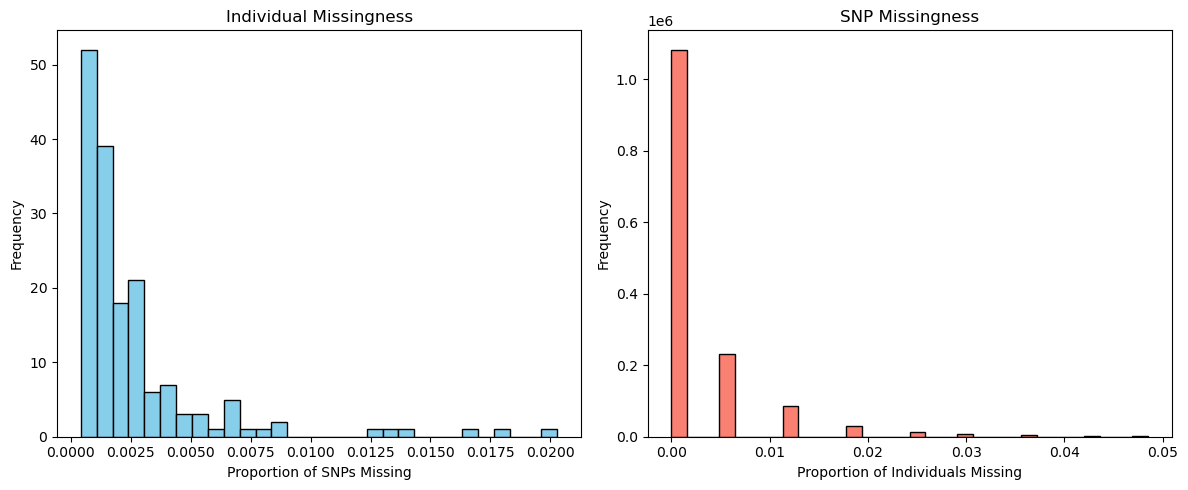

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data 
imiss = pd.read_csv("step1_missingness.imiss", sep=r'\s+')
lmiss = pd.read_csv("step1_missingness.lmiss", sep=r'\s+')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Individual missingness
ax1.hist(imiss['F_MISS'], bins=30, color='skyblue', edgecolor='black')
ax1.set_title('Individual Missingness')
ax1.set_xlabel('Proportion of SNPs Missing')
ax1.set_ylabel('Frequency')

# SNP missingness 
ax2.hist(lmiss['F_MISS'], bins=30, color='salmon', edgecolor='black')
ax2.set_title('SNP Missingness')
ax2.set_xlabel('Proportion of Individuals Missing')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()


2) Sex Discrepancy (20 pts)
a. Provide PLINK + bash commands used to run check sex discrepancy and extract flagged samples.
b. Plot histograms of the inbreeding coefficient(F) for: (i) all samples, (ii) reported males only, and (iii) reported females only.
c. If discrepancies exist: report the sample ID(s) and provide PLINK/bash command(s) used to impute sex.




In [17]:
# Check sex discrepancy
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile HapMap_3_r3_missingness_stringent_filtered --check-sex --out step2_sex

PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to step2_sex.log.
Options in effect:
  --bfile HapMap_3_r3_missingness_stringent_filtered
  --check-sex
  --out step2_sex

18432 MB RAM detected; reserving 9216 MB for main workspace.
1431211 variants loaded from .bim file.
164 people (79 males, 85 females) loaded from .fam.
112 phenotype values loaded from .fam.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 112 founders and 52 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
treat these as missing.
Total genotyping rate is 0.997997.
1431211 variants and 164 people pass filters and QC.
Among remaining phenotypes, 56 are cases and 56 are controls.

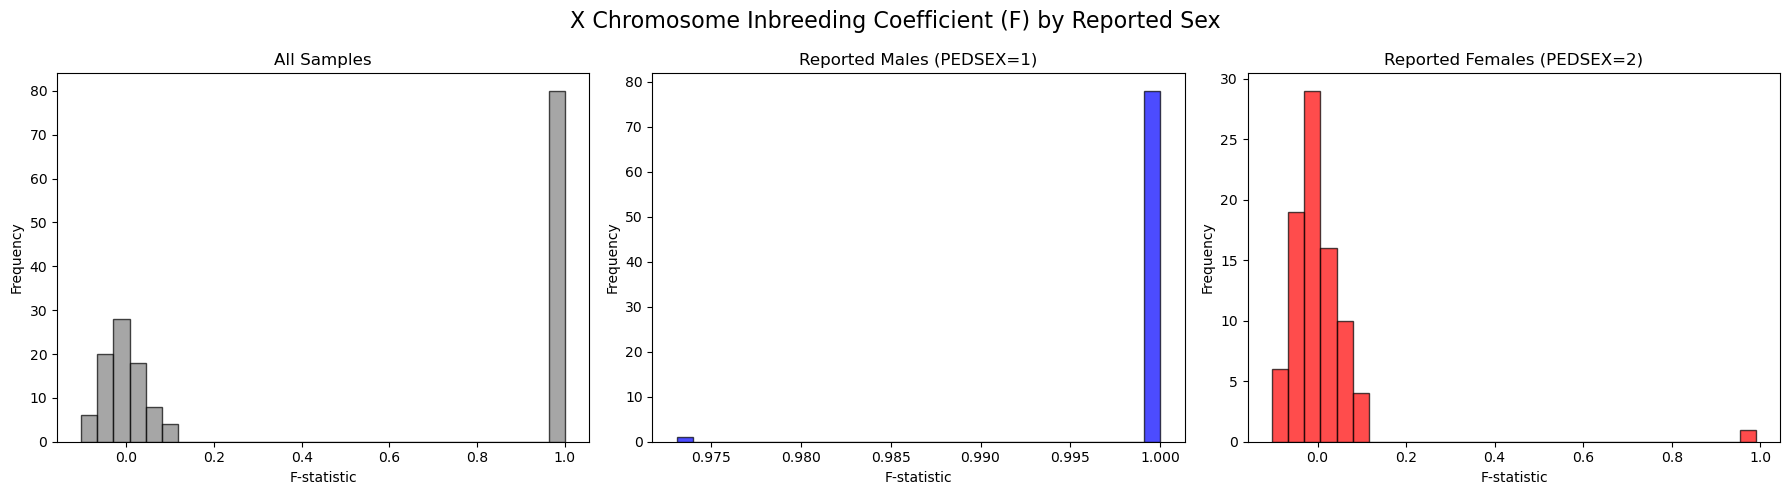

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the sexcheck data
sexcheck = pd.read_csv("step2_sex.sexcheck", sep=r'\s+')

# Separate by reported sex (1 = Male, 2 = Female)
males = sexcheck[sexcheck['PEDSEX'] == 1]
females = sexcheck[sexcheck['PEDSEX'] == 2]

# Create a figure with 3 side-by-side subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (i) All samples
axes[0].hist(sexcheck['F'], bins=30, color='gray', edgecolor='black', alpha=0.7)
axes[0].set_title('All Samples')
axes[0].set_xlabel('F-statistic')
axes[0].set_ylabel('Frequency')

# (ii) Reported Males
axes[1].hist(males['F'], bins=30, color='blue', edgecolor='black', alpha=0.7)
axes[1].set_title('Reported Males (PEDSEX=1)')
axes[1].set_xlabel('F-statistic')
axes[1].set_ylabel('Frequency')

# (iii) Reported Females
axes[2].hist(females['F'], bins=30, color='red', edgecolor='black', alpha=0.7)
axes[2].set_title('Reported Females (PEDSEX=2)')
axes[2].set_xlabel('F-statistic')
axes[2].set_ylabel('Frequency')

# Add a main title for the entire figure and adjust layout
plt.suptitle('X Chromosome Inbreeding Coefficient (F) by Reported Sex', fontsize=16)
plt.tight_layout()
plt.show()

The F-statistic is the X-chromosome inbreeding coefficient, which is a measure of heterozygosity. Because females have two copies of the X chromosome, they can carry two different alleles for a given SNP on that chromosome. Therefore, you expect a normal rate of heterozygosity. Males have one X chromosome and possess one allele for any X-chromosome SNP, so genotyping algorithms will read every X-linked SNP as homozygous. PLINK looks at the self-reported (or clinically reported) sex in your .fam file (PEDSEX) and compares it to the calculated genetic sex (SNPSEX) derived from the F-statistic.
By default, PLINK uses these thresholds to assign genetic sex:  
$F < 0.2$ $\rightarrow$ Assigned Female (SNPSEX = 2)  
$F > 0.8$ $\rightarrow$ Assigned Male (SNPSEX = 1)  
$0.2 \le F \le 0.8$ $\rightarrow$ Ambiguous

In [20]:
# --- Identifying Discrepancies ---
# Filter for samples where PLINK flagged a problem
discrepancies = sexcheck[sexcheck['STATUS'] == 'PROBLEM']

print("\n--- Sex Discrepancies Found ---")
if discrepancies.empty:
    print("No discrepancies found.")
else:
    print(discrepancies[['FID', 'IID', 'PEDSEX', 'SNPSEX', 'F']])


--- Sex Discrepancies Found ---
      FID      IID  PEDSEX  SNPSEX     F
162  1349  NA10854       2       1  0.99


In [25]:
# Impute Sex
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile HapMap_3_r3_missingness_stringent_filtered --impute-sex --make-bed --out HapMap_3_r3_sex_imputed

PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to HapMap_3_r3_sex_imputed.log.
Options in effect:
  --bfile HapMap_3_r3_missingness_stringent_filtered
  --impute-sex
  --make-bed
  --out HapMap_3_r3_sex_imputed

18432 MB RAM detected; reserving 9216 MB for main workspace.
1431211 variants loaded from .bim file.
164 people (79 males, 85 females) loaded from .fam.
112 phenotype values loaded from .fam.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 112 founders and 52 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
many commands treat these as missing.
Total genotyping rate is 0.997997.
1431211 variants and 164 people pass filters and QC.
Among

3) Minor Allele Frequency (MAF) Filtering (20 pts)
a. Provide PLINK + bash commands used to compute allele frequencies and filter low-MAF SNPs.
b. State the MAF threshold used and justify in 1-2 sentences the choice of threshold.
c. Plot MAF histograms before and after filtering (include code + plots).



In [26]:
# 1. Compute allele frequencies before filtering
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile HapMap_3_r3_sex_imputed --freq --out HapMap_3_r3_freq_before

# 2. Filter out SNPs with a Minor Allele Frequency below the defined threshold (0.05)
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile HapMap_3_r3_sex_imputed --maf 0.05 --make-bed --out HapMap_3_r3_maf_filtered

# 3. Compute allele frequencies after filtering to verify the process
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile HapMap_3_r3_maf_filtered --freq --out HapMap_3_r3_freq_after

PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to HapMap_3_r3_freq_before.log.
Options in effect:
  --bfile HapMap_3_r3_sex_imputed
  --freq
  --out HapMap_3_r3_freq_before

18432 MB RAM detected; reserving 9216 MB for main workspace.
1431211 variants loaded from .bim file.
164 people (80 males, 84 females) loaded from .fam.
112 phenotype values loaded from .fam.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 112 founders and 52 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
many commands treat these as missing.
Total genotyping rate is 0.997997.
--freq: Allele frequencies (founders only) written to
HapMap_3_r3_freq_before.frq .
PLINK v1.9.0

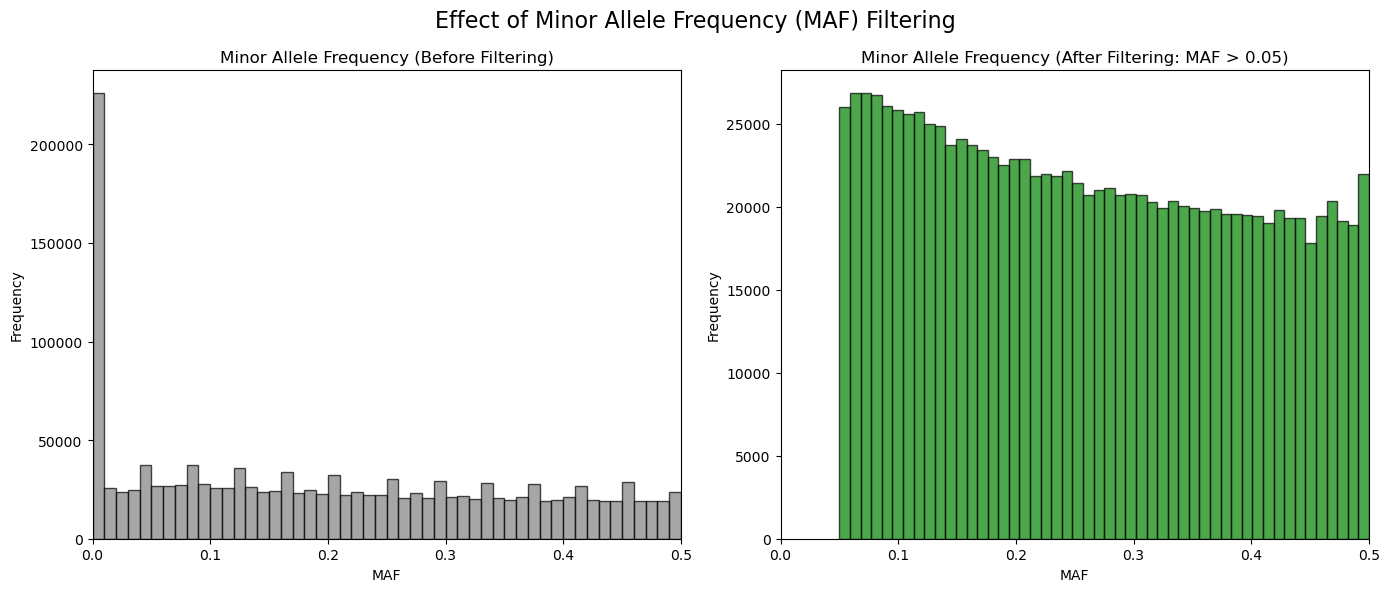

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the allele frequency data before and after filtering
freq_before = pd.read_csv("HapMap_3_r3_freq_before.frq", sep=r'\s+')
freq_after = pd.read_csv("HapMap_3_r3_freq_after.frq", sep=r'\s+')

# Initialize a figure with 2 side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram (i): MAF distribution before filtering
axes[0].hist(freq_before['MAF'], bins=50, color='gray', edgecolor='black', alpha=0.7)
axes[0].set_title('Minor Allele Frequency (Before Filtering)')
axes[0].set_xlabel('MAF')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(0, 0.5)

# Histogram (ii): MAF distribution after applying the 0.05 threshold
axes[1].hist(freq_after['MAF'], bins=50, color='green', edgecolor='black', alpha=0.7)
axes[1].set_title('Minor Allele Frequency (After Filtering: MAF > 0.05)')
axes[1].set_xlabel('MAF')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim(0, 0.5)

# Format and display the plots
plt.suptitle('Effect of Minor Allele Frequency (MAF) Filtering', fontsize=16)
plt.tight_layout()
plt.show()

Iit is standard practice to drop the sex chromosomes (X, Y) and mitochondrial DNA (MT) before proceeding to Hardy-Weinberg Equilibrium (HWE), Heterozygosity, and Relatedness calculations. The mathematical models for HWE, genomic heterozygosity, and Identity by Descent (IBD) strictly assume a diploid genome.

In [29]:
# Keep only autosomal chromosomes (1-22) for the remaining QC steps
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile HapMap_3_r3_maf_filtered --autosome --make-bed --out HapMap_3_r3_autosomes

PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to HapMap_3_r3_autosomes.log.
Options in effect:
  --autosome
  --bfile HapMap_3_r3_maf_filtered
  --make-bed
  --out HapMap_3_r3_autosomes

18432 MB RAM detected; reserving 9216 MB for main workspace.
1073788 out of 1093681 variants loaded from .bim file.
164 people (80 males, 84 females) loaded from .fam.
112 phenotype values loaded from .fam.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 112 founders and 52 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is 0.998144.
1073788 variants and 164 people pass filters and QC.
Among remaining phenotypes, 56 are cases and 56 are 

4) Hardy–Weinberg Equilibrium (HWE) Filtering (20 pts)
a. Provide PLINK + bash commands used to compute HWE and remove SNPs failing HWE.
b. Plot histogram of HWE p-values after filtering (include code + plot).



In [33]:
# - Exclude SNPs that deviate from HWE. 

# By default the --hwe option in plink only filters for controls. 
# Using a stringent HWE threshold for controls
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile HapMap_3_r3_autosomes --hwe 1e-6 --make-bed --out HapMap_3_r3_hwe_filtered

# We can use the --hwe-all option to specify that the HWE test should be applied to all samples (including cases). 
# Using a less stringent HWE threshold for cases.
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile HapMap_3_r3_hwe_filtered --hwe 1e-10 --hwe-all --make-bed --out HapMap_3_r3_hwe_filtered2

# Compute the HWE statistics on the filtered dataset to generate the p-values for plotting
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile HapMap_3_r3_hwe_filtered2 --hardy --out HapMap_3_r3_hwe_after_filter

PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to HapMap_3_r3_hwe_filtered.log.
Options in effect:
  --bfile HapMap_3_r3_autosomes
  --hwe 1e-6
  --make-bed
  --out HapMap_3_r3_hwe_filtered

18432 MB RAM detected; reserving 9216 MB for main workspace.
1073788 variants loaded from .bim file.
164 people (80 males, 84 females) loaded from .fam.
112 phenotype values loaded from .fam.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 112 founders and 52 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is 0.998144.
--hwe: 0 variants removed due to Hardy-Weinberg exact test.
1073788 variants and 164 people pass filters and QC.
Amon

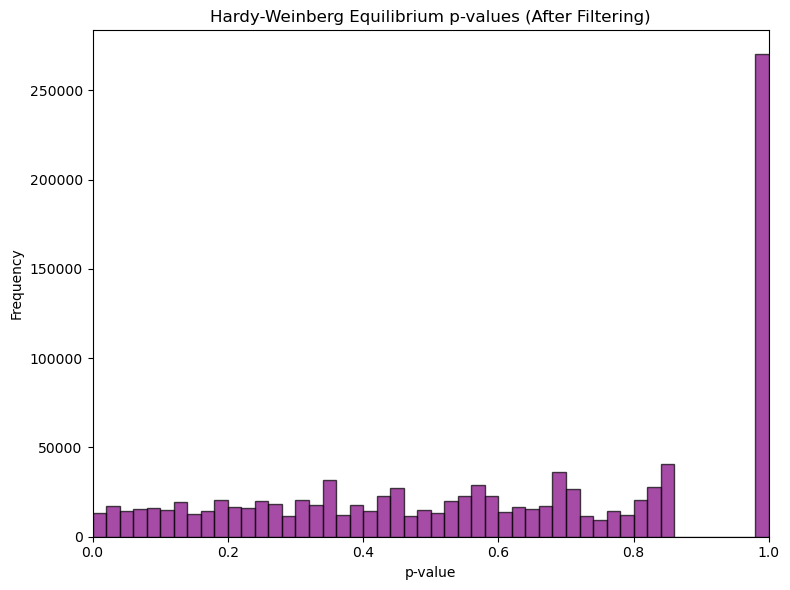

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the HWE statistics after filtering
hwe_after = pd.read_csv("HapMap_3_r3_hwe_after_filter.hwe", sep=r'\s+')

# PLINK's --hardy command calculates HWE for all samples (ALL), 
# and if phenotypes exist, for cases (AFF) and controls (UNAFF) separately.
# To avoid plotting duplicate variants, we filter for the 'ALL' test.
if 'TEST' in hwe_after.columns and 'ALL' in hwe_after['TEST'].values:
    hwe_plot_data = hwe_after[hwe_after['TEST'] == 'ALL']
else:
    hwe_plot_data = hwe_after

# Initialize the figure
plt.figure(figsize=(8, 6))

# Histogram: HWE p-values after applying the 1e-6 threshold
plt.hist(hwe_plot_data['P'], bins=50, color='purple', edgecolor='black', alpha=0.7)
plt.title('Hardy-Weinberg Equilibrium p-values (After Filtering)')
plt.xlabel('p-value')
plt.ylabel('Frequency')
plt.xlim(0, 1)

# Format and display the plot
plt.tight_layout()
plt.show()

5) Heterozygosity Rate (20 pts)
a. Provide PLINK + bash commands used to check heterozygosity rate and filter outliers.
b. Plot histogram of heterozygosity rate after filtering.
c. List removed individuals that were filtered (FID, IID).



In [37]:
# Checks for heterozygosity are performed on a set of SNPs which are not highly correlated.
# Therefore, to generate a list of non-(highly)correlated SNPs, we exclude high inversion regions (High LD regions).
# The parameters stand respectively for: the window size, the number of SNPs to shift the window at each step, and the multiple correlation coefficient (r^2) threshold for a SNP being regressed on all other SNPs simultaneously.

# Prune for Linkage Disequilibrium (LD) to ensure SNPs are independent
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile HapMap_3_r3_hwe_filtered2 --indep-pairwise 50 5 0.2 --out indepSNP  # --exclude inversion.txt

# Compute heterozygosity on the independent SNPs (Before Filtering)
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile HapMap_3_r3_hwe_filtered2 --extract indepSNP.prune.in --het --out HapMap_3_r3_het_before



PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to indepSNP.log.
Options in effect:
  --bfile HapMap_3_r3_hwe_filtered2
  --indep-pairwise 50 5 0.2
  --out indepSNP

18432 MB RAM detected; reserving 9216 MB for main workspace.
1073788 variants loaded from .bim file.
164 people (80 males, 84 females) loaded from .fam.
112 phenotype values loaded from .fam.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 112 founders and 52 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is 0.998144.
1073788 variants and 164 people pass filters and QC.
Among remaining phenotypes, 56 are cases and 56 are controls.  (52 phenotypes
are missing.

In [40]:
import pandas as pd

# Load the initial heterozygosity data
het_before = pd.read_csv("HapMap_3_r3_het_before.het", sep=r'\s+')

# Calculate the observed heterozygosity rate for each patient: 
# (Total Non-Missing - Observed Homozygous) / Total Non-Missing
het_before['HET_RATE'] = (het_before['N(NM)'] - het_before['O(HOM)']) / het_before['N(NM)']

# Calculate mean and standard deviation
mean_het = het_before['HET_RATE'].mean()
std_het = het_before['HET_RATE'].std()

# Define outlier thresholds (Mean +/- 3 SD)
lower_bound = mean_het - (3 * std_het)
upper_bound = mean_het + (3 * std_het)
print(f"Heterozygosity Rate Mean: {mean_het:.4f}")
print(f"Heterozygosity Rate Std Dev: {std_het:.4f}\n")

# Identify outliers
outliers = het_before[(het_before['HET_RATE'] < lower_bound) | (het_before['HET_RATE'] > upper_bound)]

print("--- Removed Individuals (FID, IID) ---")
if outliers.empty:
    print("No heterozygosity outliers detected.")
    # Create an empty file to prevent PLINK from throwing a file-not-found error
    open("fail-het.txt", "w").close()
else:
    print(outliers[['FID', 'IID', 'HET_RATE']])
    # Save the FIDs and IIDs to a text file for the PLINK --remove command
    outliers[['FID', 'IID']].to_csv("fail-het.txt", sep='\t', index=False, header=False)

Heterozygosity Rate Mean: 0.3539
Heterozygosity Rate Std Dev: 0.0030

--- Removed Individuals (FID, IID) ---
      FID      IID  HET_RATE
79   1330  NA12342  0.342239
104  1459  NA12874  0.339282


In [41]:
# 3. Filter out the outlier individuals
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile HapMap_3_r3_hwe_filtered2 --remove fail-het.txt --make-bed --out HapMap_3_r3_het_filtered

# 4. Compute heterozygosity on the clean dataset to generate data for the final plot
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile HapMap_3_r3_het_filtered --extract indepSNP.prune.in --het --out HapMap_3_r3_het_after

PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to HapMap_3_r3_het_filtered.log.
Options in effect:
  --bfile HapMap_3_r3_hwe_filtered2
  --make-bed
  --out HapMap_3_r3_het_filtered
  --remove fail-het.txt

18432 MB RAM detected; reserving 9216 MB for main workspace.
1073788 variants loaded from .bim file.
164 people (80 males, 84 females) loaded from .fam.
112 phenotype values loaded from .fam.
--remove: 162 people remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 110 founders and 52 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate in remaining samples is 0.998169.
1073788 variants and 162 people pass filters and 

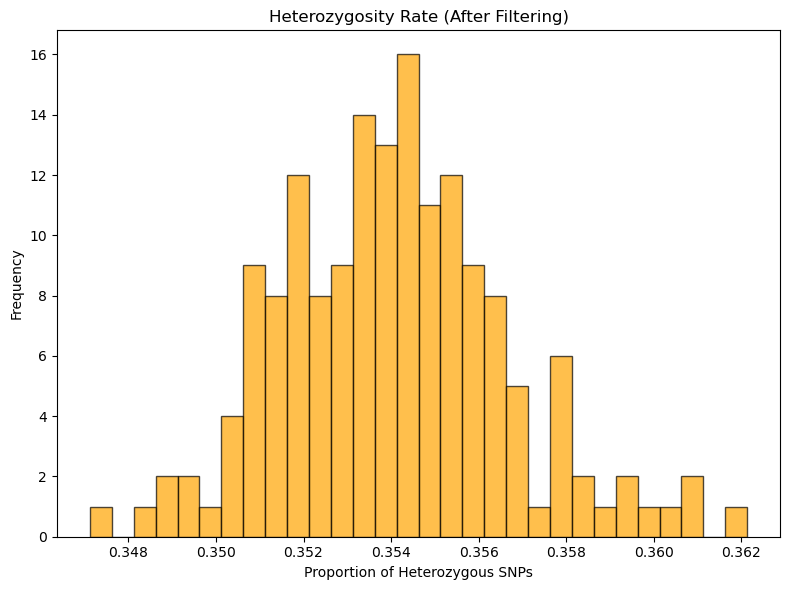

In [42]:
import matplotlib.pyplot as plt

# Load the heterozygosity data after filtering
het_after = pd.read_csv("HapMap_3_r3_het_after.het", sep=r'\s+')

# Calculate the observed heterozygosity rate
het_after['HET_RATE'] = (het_after['N(NM)'] - het_after['O(HOM)']) / het_after['N(NM)']

# Initialize the figure
plt.figure(figsize=(8, 6))

# Histogram: Heterozygosity rate after outlier removal
plt.hist(het_after['HET_RATE'], bins=30, color='orange', edgecolor='black', alpha=0.7)
plt.title('Heterozygosity Rate (After Filtering)')
plt.xlabel('Proportion of Heterozygous SNPs')
plt.ylabel('Frequency')

# Format and display the plot
plt.tight_layout()
plt.show()

6) Relatedness (20 pts)
a. Provide PLINK + bash commands used to compute relatedness and filter related samples (state PIHAT threshold).
b. Report final #samples and #SNPs after filtering.

In [54]:
# Compute missingness to get the call rates (generates .imiss file)
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile HapMap_3_r3_het_filtered --missing --out HapMap_3_r3_missing_for_ibd

# Compute Identity by Descent (IBD) using the LD-pruned SNPs  (generates .genome file)
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile HapMap_3_r3_het_filtered --extract indepSNP.prune.in --genome --out HapMap_3_r3_ibd
# .genome file contains the following columns:
# RT: Relationship Type. This is inferred strictly from your .fam file (e.g., UN = Unrelated, PO = Parent/Offspring). Because you are working with a cohort without declared family structures, it correctly defaults to UN.
# EZ: The expected IBD (Identity by Descent) sharing value based only on the relationship declared in the .fam file. It says NA here because there are no declared family links.
# Z0: $P(\text{IBD}=0)$. The calculated probability that the pair shares exactly 0 alleles identical by descent.
# Z1: $P(\text{IBD}=1)$. The probability that the pair shares exactly 1 allele identical by descent.
# Z2: $P(\text{IBD}=2)$. The probability that the pair shares exactly 2 alleles identical by descent.
# PI_HAT: ($\hat{\pi}$). The overall estimated proportion of alleles shared identical by descent. The formula is $Z2 + 0.5 \times Z1$. This is the primary metric you used earlier to filter your dataset.


PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to HapMap_3_r3_missing_for_ibd.log.
Options in effect:
  --bfile HapMap_3_r3_het_filtered
  --missing
  --out HapMap_3_r3_missing_for_ibd

18432 MB RAM detected; reserving 9216 MB for main workspace.
1073788 variants loaded from .bim file.
162 people (78 males, 84 females) loaded from .fam.
110 phenotype values loaded from .fam.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 110 founders and 52 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is 0.998169.
--missing: Sample missing data report written to
HapMap_3_r3_missing_for_ibd.imiss, and variant-based missing data report


In [55]:
import pandas as pd

# Load the IBD and Missingness data
ibd_data = pd.read_csv("HapMap_3_r3_ibd.genome", sep=r'\s+')
imiss_data = pd.read_csv("HapMap_3_r3_missing_for_ibd.imiss", sep=r'\s+')

# Create a dictionary to quickly look up missingness by (FID, IID)
# F_MISS is the proportion of missing SNPs (higher F_MISS = lower call rate)
missing_dict = imiss_data.set_index(['FID', 'IID'])['F_MISS'].to_dict()

# Set PIHAT threshold
pihat_threshold = 0.2

# Filter for pairs that exceed the threshold
related_pairs = ibd_data[ibd_data['PI_HAT'] > pihat_threshold]

individuals_to_remove = set()

for index, row in related_pairs.iterrows():
    ind1 = (row['FID1'], row['IID1'])
    ind2 = (row['FID2'], row['IID2'])
    
    # Get missingness for both individuals (default to 0 if not found)
    miss1 = missing_dict.get(ind1, 0)
    miss2 = missing_dict.get(ind2, 0)
    
    # Check if we have already flagged one of these individuals
    if ind1 not in individuals_to_remove and ind2 not in individuals_to_remove:
        # Flag the individual with the HIGHER missingness rate
        if miss1 > miss2:
            individuals_to_remove.add(ind1)
        else:
            individuals_to_remove.add(ind2) # Also catches ties

print("--- Relatedness & Call Rate Filtering ---")
if individuals_to_remove:
    remove_df = pd.DataFrame(list(individuals_to_remove), columns=['FID', 'IID'])
    print(f"Flagged {len(remove_df)} individuals for removal due to PIHAT > {pihat_threshold}.")
    remove_df.to_csv("fail-ibd.txt", sep='\t', index=False, header=False)
else:
    print("No highly related pairs found.")
    open("fail-ibd.txt", "w").close()

--- Relatedness & Call Rate Filtering ---
Flagged 69 individuals for removal due to PIHAT > 0.2.


In [56]:
related_pairs

,FID1,IID1,FID2,IID2,RT,EZ,Z0,Z1,Z2,PI_HAT,PHE,DST,PPC,RATIO
215,1377,NA11891,1377,NA10865,PO,0.5,0.0000,1.0000,0.0000,0.5000,0,0.823438,1.0,3631.00
376,1349,NA11843,1349,NA10853,PO,0.5,0.0021,0.9908,0.0071,0.5025,-1,0.824851,1.0,933.25
521,1330,NA12341,1330,NA12335,PO,0.5,0.0000,1.0000,0.0000,0.5000,0,0.823011,1.0,928.00
993,1463,NA12877,1463,NA12890,PO,0.5,0.0000,1.0000,0.0000,0.5000,0,0.823034,1.0,928.50
1019,1463,NA12877,1463,NA12889,PO,0.5,0.0143,0.9799,0.0058,0.4957,0,0.823351,1.0,147.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12645,1459,NA12864,1459,NA12872,PO,0.5,0.0000,1.0000,0.0000,0.5000,0,0.822241,1.0,1860.50
12655,1459,NA12864,1459,NA12873,PO,0.5,0.0000,1.0000,0.0000,0.5000,-1,0.822694,1.0,737.80
12684,1444,NA12751,1444,NA12740,PO,0.5,0.0017,0.9926,0.0057,0.5020,0,0.824649,1.0,1851.00
12707,1362,NA10861,1362,NA11994,PO,0.5,0.0009,0.9948,0.0043,0.5017,0,0.824475,1.0,1863.50


In [57]:
# Remove the cryptically related individuals (lowest call rates dropped)
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile HapMap_3_r3_het_filtered --remove fail-ibd.txt --make-bed --out HapMap_3_r3_relatedness_filtered

# Filter for founders only (keeps only individuals without parents in the dataset)
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile HapMap_3_r3_relatedness_filtered --filter-founders --make-bed --out HapMap_3_r3_qc_final

# Recalculate IBD on the final clean dataset for plotting
! /Users/kmlanderos/Downloads/plink_mac_20250819/plink --bfile HapMap_3_r3_qc_final --extract indepSNP.prune.in --genome --out HapMap_3_r3_ibd_after

PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to HapMap_3_r3_relatedness_filtered.log.
Options in effect:
  --bfile HapMap_3_r3_het_filtered
  --make-bed
  --out HapMap_3_r3_relatedness_filtered
  --remove fail-ibd.txt

18432 MB RAM detected; reserving 9216 MB for main workspace.
1073788 variants loaded from .bim file.
162 people (78 males, 84 females) loaded from .fam.
110 phenotype values loaded from .fam.
--remove: 93 people remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 76 founders and 17 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate in remaining samples is 0.99861.
1073788 variants and 93 people pass f

<>:25: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
/var/folders/_7/04cflckd1md8652444n3682j8w0jjt/T/ipykernel_52827/3104415402.py:25: SyntaxWarning: invalid escape sequence '\l'
  axes[1].set_title('Pairwise Relatedness (After Filtering: PI_HAT $\leq$ 0.2)')


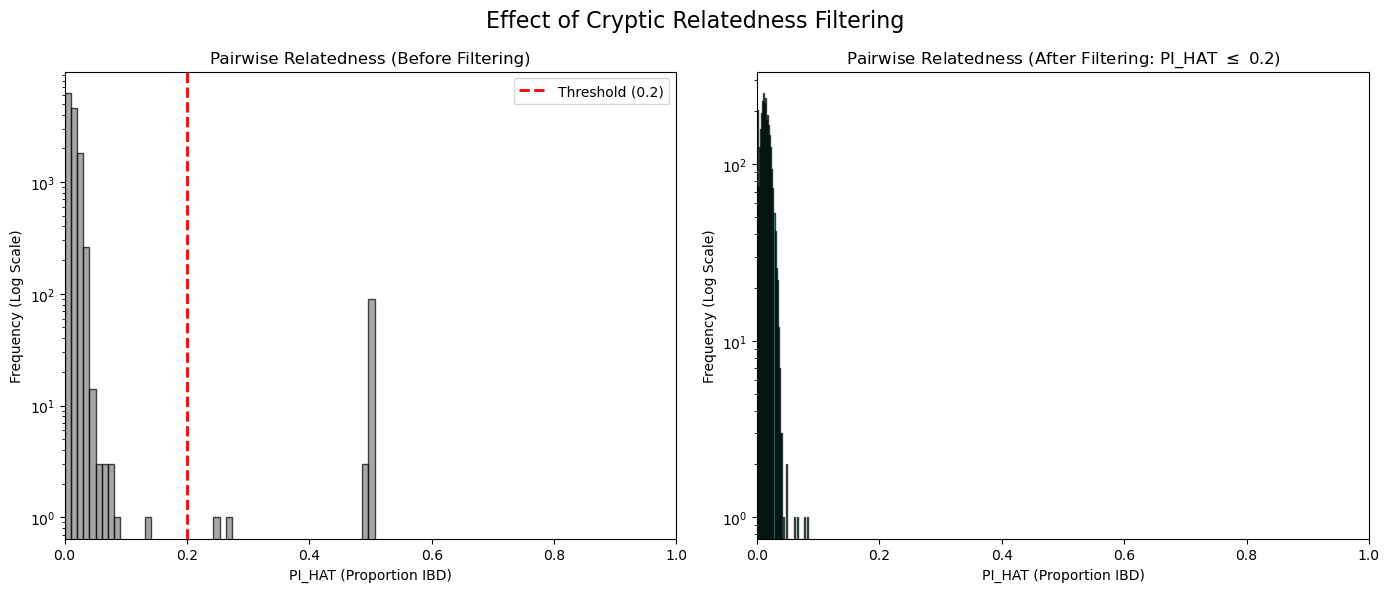

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the before and after IBD calculations
ibd_before = pd.read_csv("HapMap_3_r3_ibd.genome", sep=r'\s+')
ibd_after = pd.read_csv("HapMap_3_r3_ibd_after.genome", sep=r'\s+')

# Initialize the figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram (i): PIHAT before filtering
# We use a log scale for the y-axis because the vast majority of pairs 
# will have a PI_HAT near 0, which drowns out the visual of the highly related pairs.
axes[0].hist(ibd_before['PI_HAT'], bins=50, color='gray', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0.2, color='red', linestyle='dashed', linewidth=2, label='Threshold (0.2)')
axes[0].set_title('Pairwise Relatedness (Before Filtering)')
axes[0].set_xlabel('PI_HAT (Proportion IBD)')
axes[0].set_ylabel('Frequency (Log Scale)')
axes[0].set_yscale('log')
axes[0].set_xlim(0, 1)
axes[0].legend()

# Histogram (ii): PIHAT after filtering
axes[1].hist(ibd_after['PI_HAT'], bins=50, color='teal', edgecolor='black', alpha=0.7)
axes[1].set_title('Pairwise Relatedness (After Filtering: PI_HAT $\leq$ 0.2)')
axes[1].set_xlabel('PI_HAT (Proportion IBD)')
axes[1].set_ylabel('Frequency (Log Scale)')
axes[1].set_yscale('log')
axes[1].set_xlim(0, 1)

# Format and display
plt.suptitle('Effect of Cryptic Relatedness Filtering', fontsize=16)
plt.tight_layout()
plt.show()